# Analiza danych


<span style="color: orange;">Tak, dla uporządkowania, to na pomarańczowo piszę wszystko, co z końcowej wersji powinno zniknąć :) </span>

#### [Zbiór danych zaczerpnięty ze strony www.kaggle.com](https://www.kaggle.com/datasets/shashanks1202/apartment-rent-data).

[Na licencji MIT](https://www.mit.edu/~amini/LICENSE.md)

 Copyright (c) 2013 Mark Otto.</br>
 Copyright (c) 2017 Andrew Fong.

 Zbiór danych zawiera szczegółowe informacje o wynajmie mieszkań w Stanach Zjednoczonych Ameryki. Zawarte w zbiorze dane obejmują ważniejsze informacje dotyczące wynajmu. 
 </BR>Są to :
- kategoria oferowanej nieruchomości,
- lokalizacja (adres, nazwa miasta, stan, szerokość i długość geograficzną), 
- źródło ogłoszenia,
- szczegóły nieruchomości obejmujące informacje o kategorii mieszkania, tytule własności, bryle, udogodnieniach, liczbie łazienek, sypialni i powierzchni mieszkania (w stopach kwadratowych).
- cenę wynajmu (price), 
- cenę wyświetlaną (price_display), 
- typ ceny (price_type)
- Informacja, czy wymagana jest opłata.
- Informacja, czy oferta ma załączone zdjęcie (has_photo),
- Informacja, czy zwierzęta są dozwolone (pets_allowed),
- Waluta (zawsze USD)
- Czas utworzenia oferty.



#### <span style="color: deepskyblue;">Przebieg czyszczenia danych opisany jest w pliku [raport.ipynb](raport.ipynb)    </span>

Analiza jest wykonana dla oczyszczonego pliku [apartments_clean.csv](\data\apartments_clean.csv)

#### <span style="color: deepskyblue;">Analiza dotycząca oferowanych powierzchni nieruchomości w ujęciu geograficznym   </span>



In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as ss
import seaborn as sns
import missingno as msno
import plotly.express as px

%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

df = pd.read_csv("data/apartments_clean.csv", sep=';', encoding="cp1250")
df.head(1)

C:\Users\Grażyna\AppData\Local\Temp\ipykernel_16488\534623597.py:12: DtypeWarning: Columns (0: address) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/apartments_clean.csv", sep=';', encoding="cp1250")


,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,...,0,0,0,0,0,0,0,0,0,4.049815


In [3]:
df_state = pd.read_csv("data/przypisanie_stanowUSA.csv", sep=';', encoding="cp1250")
df_state.head(1)

,Stan,Skrot,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie
0,Alabama,AL,South,CST / EST,Tak,Tak,Nie


In [4]:

# dołącz nazwę stanu
df = df.merge(
    df_state[['Skrot', 'Stan']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz region
df = df.merge(
    df_state[['Skrot', 'Region']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Strefa czasowa
df = df.merge(
    df_state[['Skrot', 'Strefa czasowa']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Stan rolniczy
df = df.merge(
    df_state[['Skrot', 'Stan rolniczy']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Stan przemyslowy
df = df.merge(
    df_state[['Skrot', 'Stan przemyslowy']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Wazny turystycznie
df = df.merge(
    df_state[['Skrot', 'Wazny turystycznie']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')
df.head(2)


,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,View,Washer Dryer,Wood Floors,price_per_sqft,Stan,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,...,0,0,0,4.049815,California,West,PST,Tak,Tak,Tak
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,...,0,0,0,0.833333,Virginia,South,EST,Nie,Tak,Tak


In [5]:
# na podstawie pól logicznych określam charakter stanu
df['charakter'] = (
    np.where(df['Stan rolniczy']=="Tak", 'Roln ', '') +
    np.where(df['Stan przemyslowy']=="Tak", 'Przem ', '') +
    np.where(df['Wazny turystycznie']=="Tak", 'Turyst', '')
)

df['charakter'] = df['charakter'].str.strip()

df.head(5)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Washer Dryer,Wood Floors,price_per_sqft,Stan,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie,charakter
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,...,0,0,4.049815,California,West,PST,Tak,Tak,Tak,Roln Przem Turyst
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,...,0,0,0.833333,Virginia,South,EST,Nie,Tak,Tak,Przem Turyst
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,2.0,3.0,USD,No,Thumbnail,NaN,1395.0,...,0,0,0.845455,North Carolina,South,EST,Tak,Tak,Tak,Roln Przem Turyst
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1600.0,...,0,0,1.951220,California,West,PST,Tak,Tak,Tak,Roln Przem Turyst
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",975.0,...,0,0,1.562500,New Mexico,West,MST,Nie,Nie,Tak,Turyst


In [6]:
df1 = df[(df["square_feet"] <= 300)]
df1["bin_square_feet"] = pd.cut(
    df1["square_feet"],
    bins=[0, 200, 250, 300, float("inf")],
    labels=["0-200", "200-250", "250-300", "300+"]
)
#df1.head(3)
#df1.to_csv('D:\\tmp\\df1.csv', sep=';', index=False, encoding='utf-8')

In [7]:
df2 = df[(df["square_feet"] > 300) & ( df["square_feet"] <= 2100) ]
df2["bin_square_feet"] = pd.cut(
    df2["square_feet"],
    bins=[300,500, 700, 1000, 1500, 2000, 2100, float("inf")],
    labels=["do 500", " do 700", " do 1000", "do 1500",
            " do 2000","do 2100", "2100+"]
)
#df2.head(3)

In [8]:
df3 = df[(df["square_feet"] > 2100)]
df3["bin_square_feet"] = pd.cut(
    df3["square_feet"],
    bins=[2100,2500,3000, 4000, 5000, 10000, float("inf")],
    labels=["do 2500", " do 3000", " do 4000", "do 5000","do 10000", "10000+"]
)
#df3.head(3)

In [9]:
df["bin_square_feet"] = pd.cut(
    df["square_feet"],
    bins=[300, 500, 700, 1000, 1500, 2000, 2500, float("inf")],
    labels=["0-300", "300-500", "500-700", "700-1000", "1000-1500","1500-2000","2000-2500"]
)
df.head(2)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Wood Floors,price_per_sqft,Stan,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie,charakter,bin_square_feet
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,...,0,4.049815,California,West,PST,Tak,Tak,Tak,Roln Przem Turyst,300-500
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,...,0,0.833333,Virginia,South,EST,Nie,Tak,Tak,Przem Turyst,700-1000


#### Rozkład wartości powierzchni według Regionu USA dla różnych grup nieruchomości

In [10]:
# Wykres na którym na osi x będzie charakter, na osi y przedział_powierzchni, 
# kolorem określony stan, a wielkość kropki ma obrazować ilość linii w pliku odpowiadających kropce.

# zliczenie rekordów dla każdej kombinacji
agg = (
    df.groupby(
        ["charakter", "bin_square_feet", "Region"]
    )
    .size()
    .reset_index(name="liczba")
)

#print(agg.head())

# wykres

region_colors = {
    "Northeast": "green",
    "Midwest": "yellow",
    "South": "orange",
    "West": "lightgreen"
}
charakter_colors = {
    "Roln": "green",
    "Roln Przem": "darkolivegreen",
    "Roln Przem Turyst": "lightgreen",
    "Roln Turyst": "darkgoldenrod",
    "Przem":"brown",
    "Przem Turyst": "darkorange",
    "Turyst": "yellow",
    "": "skyblue"
}
fig = px.scatter(
    agg,
    x="charakter",
    y="bin_square_feet",
    color="Region",
    color_discrete_map=region_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni i Regionu USA"
)

#fig.update_layout(
#    width=1200,
#    height=800
#)

fig.show()


Uszczegółowienie powyższego wykresu dla grup ofert o powierzchni małej, sredniej i dużej.

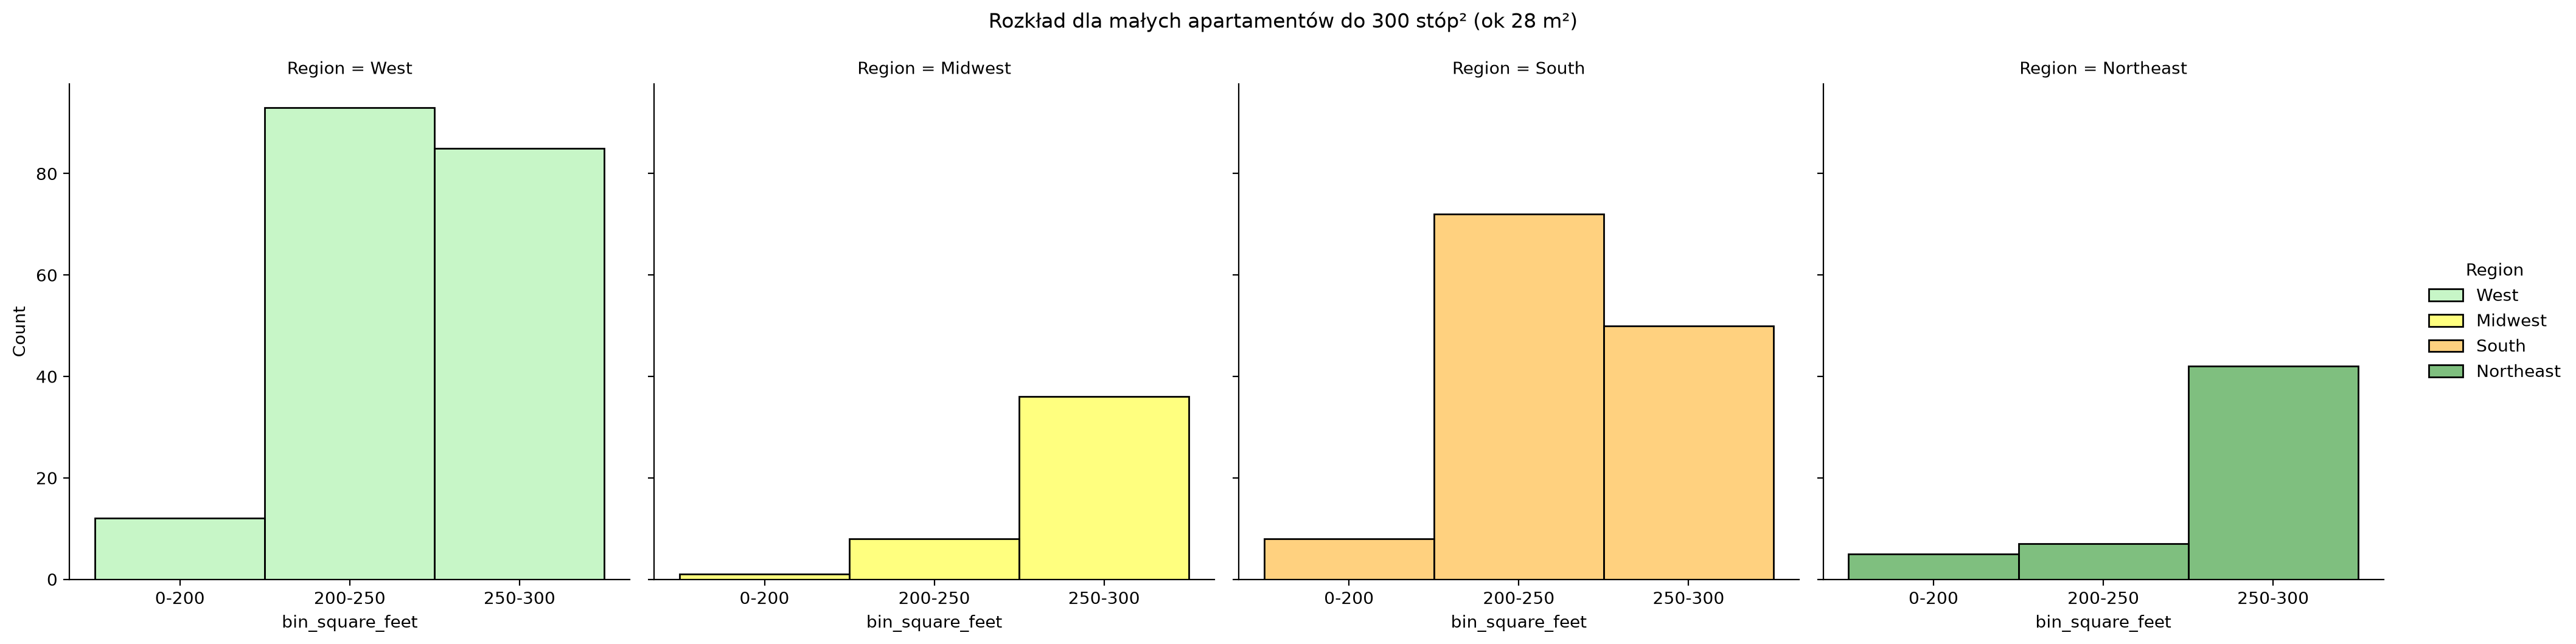

In [11]:
sns.displot(
    data=df1,
    x="bin_square_feet",
    col="Region",
    hue="Region",
    palette=region_colors
    
)
plt.suptitle("Rozkład dla małych apartamentów do 300 stóp² (ok 28 m²)", y=1.05)
plt.show()

Widoczna zależność - wśród nieruchomości małych Regiony Northeast oraz Midwest mają przewagę ofert z przedziału 250 - 300 stóp²
Dla pozostałych większość tego typu ofert dotyczy przedziału 200 - 250 stóp²

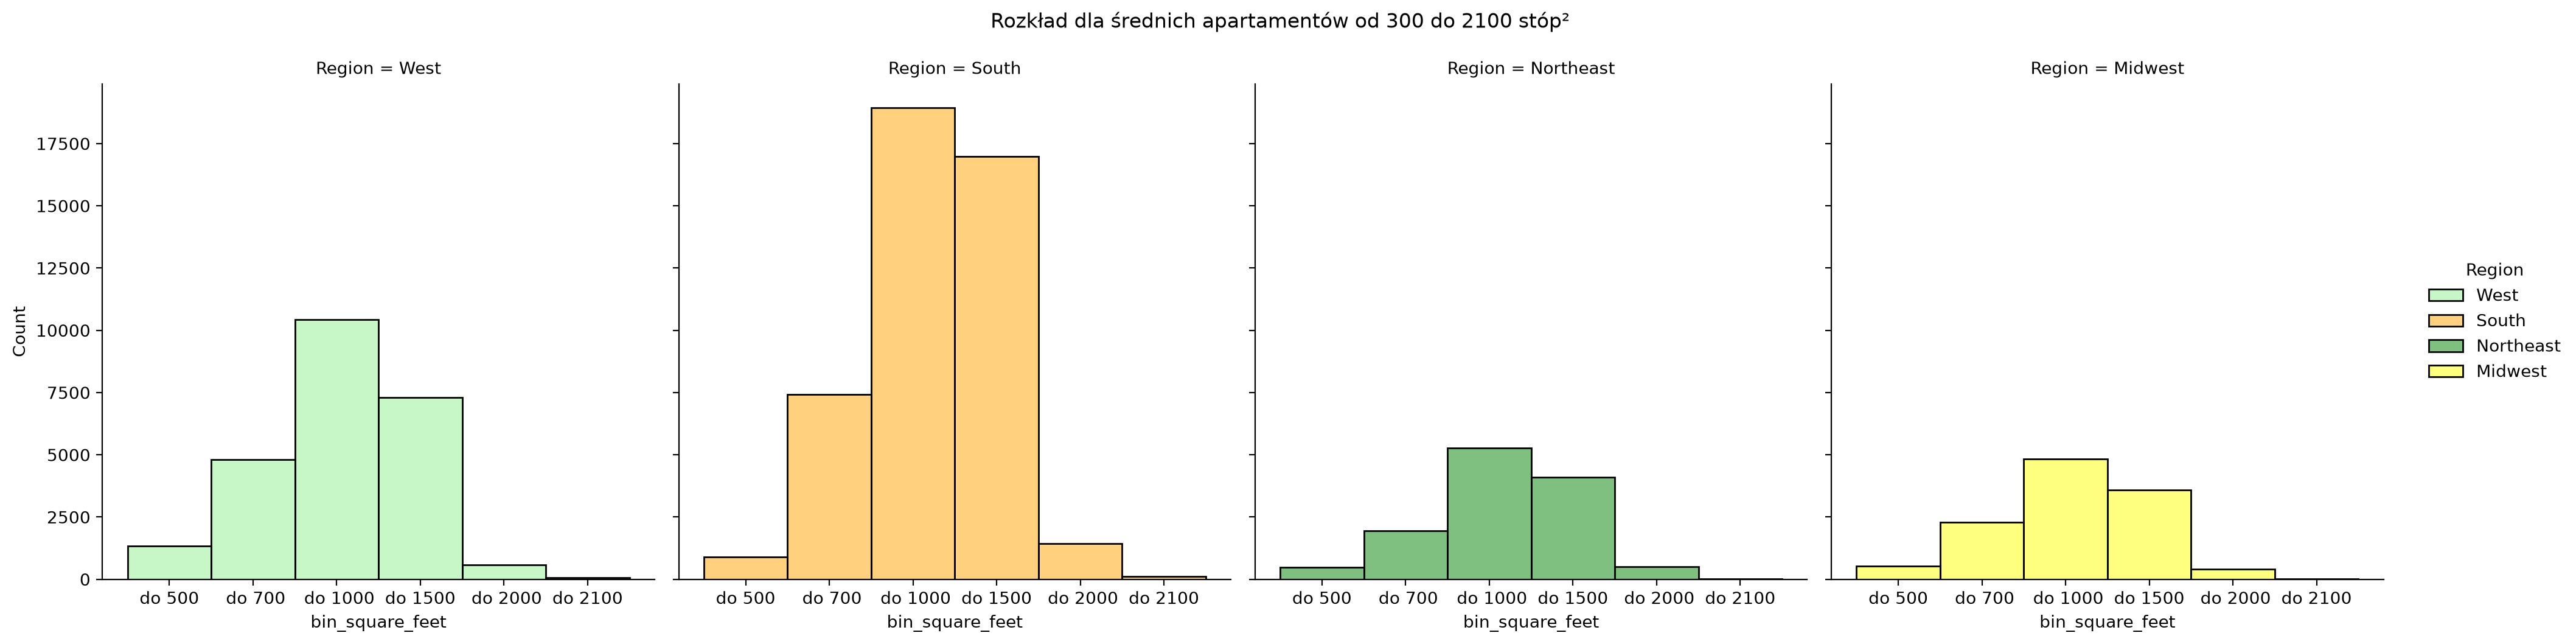

In [12]:
sns.displot(
    data=df2,
    x="bin_square_feet",
    col="Region",
    hue="Region",
    palette=region_colors
    
)

plt.suptitle("Rozkład dla średnich apartamentów od 300 do 2100 stóp² ", y=1.05)
plt.show()


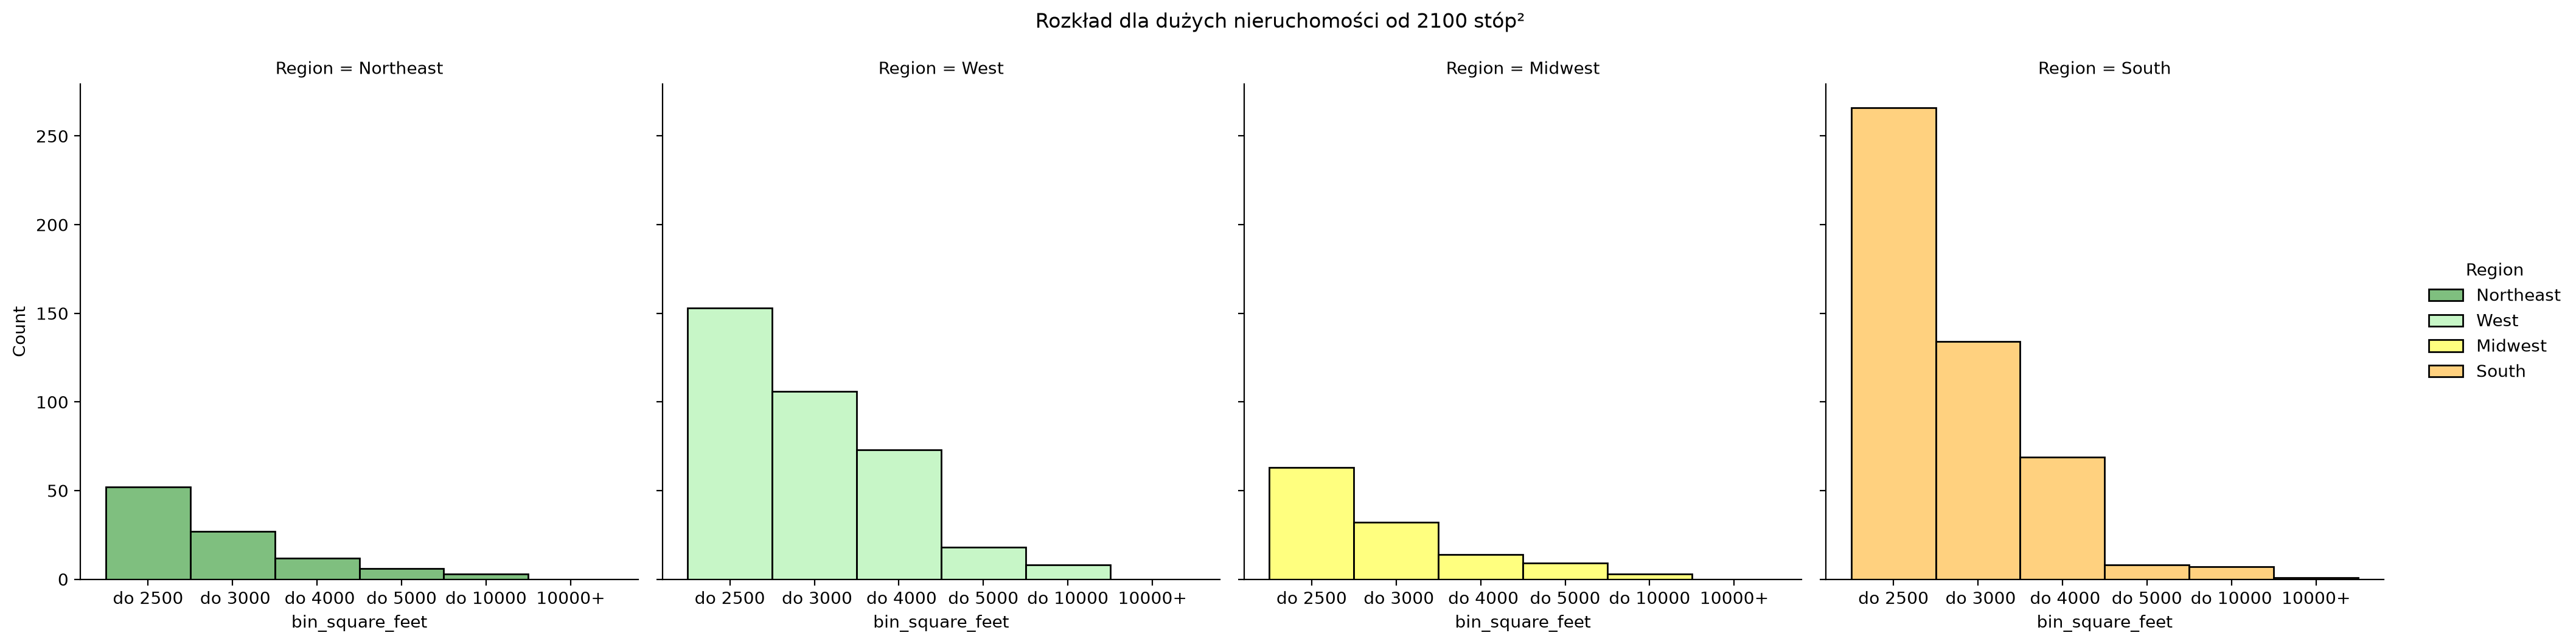

In [13]:
sns.displot(
    data=df3,
    x="bin_square_feet",
    col="Region",
    hue="Region",
    palette=region_colors
    
)

plt.suptitle("Rozkład dla dużych nieruchomości od 2100 stóp² ", y=1.05)
plt.show()

In [14]:
# wykres na którym na osi x będzie region, na osi y przedział_powierzchni, 
# kolorem określony charakter, a wielkość kropki ma obrazować ilość linii w pliku odpowiadających kropce.

# zliczenie rekordów dla każdej kombinacji
agg = (
    df.groupby(
        ["charakter", "bin_square_feet", "Region"]
    )
    .size()
    .reset_index(name="liczba")
)

#print(agg.head())

# wykres
fig = px.scatter(
    agg,
    x="Region",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
             "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg Regionu USA, przedziału powierzchni i charakteru"
)

#fig.update_layout(
#    width=1200,
#    height=800
#)

fig.show()


In [15]:
df_West = df[(df["Region"] == "West")]

df_West.head(3)
agg_West = (
    df_West.groupby(
        ["charakter", "bin_square_feet", "state"]
    )
    .size()
    .reset_index(name="liczba")
)

# wykres
fig = px.scatter(
    agg_West,
    x="state",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni dla Regionu West USA"
)

fig.update_layout()



In [16]:
df_South = df[(df["Region"] == "South")]

df_South.head(3)
agg_South = (
    df_South.groupby(
        ["charakter", "bin_square_feet", "state"]
    )
    .size()
    .reset_index(name="liczba")
)

# wykres
fig = px.scatter(
    agg_South,
    x="state",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni dla Regionu South USA"
)

fig.update_layout()



In [17]:
df_Northeast = df[(df["Region"] == "Northeast")]

df_Northeast.head(3)
agg_Northeast = (
    df_Northeast.groupby(
        ["charakter", "bin_square_feet", "state"]
    )
    .size()
    .reset_index(name="liczba")
)

# wykres
fig = px.scatter(
    agg_Northeast,
    x="state",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni dla Regionu Northeast USA"
)

fig.update_layout()


In [18]:
df_Midwest = df[(df["Region"] == "Midwest")]

df_Midwest.head(3)
agg_Midwest = (
    df_Midwest.groupby(
        ["charakter", "bin_square_feet", "state"]
    )
    .size()
    .reset_index(name="liczba")
)

# wykres
fig = px.scatter(
    agg_Midwest,
    x="state",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni dla Regionu Midwest USA"
)

fig.update_layout()

#### Interpretacja wyniku

Wykresy obrazują charakter różnych regionów i stanów zgodnie z dołączonym mapowanim. 
Nie widać dużej zależności powierzchni oferowanych nieruchomości od charakteru stanu. Najwięcej ofert jest w przedziale nieruchomości średnich niezależnie od regionu. 

Wcześniej w tekście przy wykresie dotyczącym małych nieruchomości wskazano zależność - wśród nieruchomości małych Regiony Northeast oraz Midwest mają przewagę ofert z przedziału 250 - 300 stóp²
Dla pozostałych większość tego typu ofert dotyczy przedziału 200 - 250 stóp²

### <span style="color: deepskyblue;">Analiza dotycząca ......<span style="color: orange;">tu miejsce na kolejne pomysły analiz </span>..........  </span>